# Классификация изображений

## Установка зависимостей

In [1]:
import torch
import numpy as np

train_on_gpu = torch.cuda.is_available()

if not train_on_gpu:
    print('CUDA is not available.  Training on CPU ...')
else:
    print('CUDA is available!  Training on GPU ...')

CUDA is available!  Training on GPU ...


In [2]:
!nvidia-smi

Sun May  3 14:06:36 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   38C    P8              9W /   70W |       3MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import pickle
from skimage import io

from tqdm import tqdm, tqdm_notebook
from PIL import Image
from pathlib import Path

from torchvision import transforms
from torchvision.transforms import v2

import torchsummary

from multiprocessing.pool import ThreadPool
from sklearn.preprocessing import LabelEncoder
from torch.utils.data import Dataset, DataLoader
import torch.nn as nn

from matplotlib import colors, pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings(action='ignore', category=DeprecationWarning)

### Проверим версии Python и библиотек

In [4]:
!python --version
from importlib.metadata import version
for b in ['torch', 'torchvision', 'tqdm', 'matplotlib', 'seaborn', 'Pillow']:
    print(b + ' version: '+ version(b))

Python 3.12.13
torch version: 2.10.0+cu128
torchvision version: 0.25.0+cu128
tqdm version: 4.67.3
matplotlib version: 3.10.0
seaborn version: 0.13.2
Pillow version: 11.3.0


### Определим константы

In [5]:
DATA_MODES = ['train', 'val', 'test']
DEVICE = torch.device("cuda")
TRAIN_DIR = Path('/content/train')
TEST_DIR = Path('/content/testset')
NORMALIZE_MEAN = [0.485, 0.456, 0.406]
NORMALIZE_STD = [0.229, 0.224, 0.225]
RESCALE_SIZE = [224, 224]

## Загрузка и обработка данных

Скачиваем изображение по ссылке

In [6]:
!gdown 1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1

Downloading...
From (original): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1
From (redirected): https://drive.google.com/uc?id=1RxBQiZgRAfio2tWhEE7lzZ6IaJzLheH1&confirm=t&uuid=1809b732-1c21-4061-b944-d9c3df5f0943
To: /content/journey-springfield.zip
100% 546M/546M [00:04<00:00, 123MB/s]


In [7]:
!unzip -q /content/journey-springfield.zip

Структура файлов в папках train и test: \
train - изображения персонажей разложены по папкам, которые названы по именам персонажей. \
test - изображения, для которых необходимо сделать прогноз.

In [8]:
train_val_files = sorted(list(TRAIN_DIR.rglob('*.jpg')))
test_files = sorted(list(TEST_DIR.rglob('*.jpg')))

Преобразуем имена родительских директорий, зададим числовые метки классов для энкодера. label_encoder находит все уникальные классы в наших данных и присваивает каждому классу число.

In [9]:
label_encoder = LabelEncoder()
train_val_labels = [path.parent.name for path in train_val_files]
label_encoder.fit(train_val_labels)

LabelEncoder()

Разделим выборку на обучающую и валидационную части.

In [10]:
from sklearn.model_selection import train_test_split

train_files, val_files = train_test_split(train_val_files, test_size = 0.25, stratify=train_val_labels)

### Создадим Datasets и Dataloaders

Создадим класс SimpsonDataset, который из списка файлов создаст необходимый Dataset. \
- класс будет наследовать от класса Dataset
- переопределим методы `__init__`, `__len__` и `__getitem__`

In [ ]:
class SimpsonDataset(Dataset):
  def __init__(self, files, label_encoder, mode):
    super().__init__()
    self.files = sorted(files)
    self.mode = mode
    if self.mode not in DATA_MODES:
        print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
        raise NameError

    self.label_encoder = label_encoder
    self.len_ = len(self.files)

  def __len__(self):
    return self.len_

  def __getitem__(self, index):
    x = self.load_image(self.files[index])
    x = self.transform_images_to_tensors(x)

    if self.mode == 'test':
      return x
    else:
      path = self.files[index]
      y = self.label_encoder.transform([path.parent.name,]).item()
      return x, y

  # принимает путь к изображению и возвращает само изображение
  def load_image(self, file):
    image = Image.open(file)
    image.load()
    return image

  # преобразует изображение в тензор
  def transform_images_to_tensors(self, image):
    if self.mode == 'train':
      transform = v2.Compose([
          v2.PILToTensor(),
          v2.ToDtype(torch.float32, scale = True),
          v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
          #v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
          v2.Resize(RESCALE_SIZE),
      ])
    else:
      transform = v2.Compose([
          v2.PILToTensor(),
          v2.ToDtype(torch.float32, scale = True),
          v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
          v2.Resize(RESCALE_SIZE)
      ])

    tensor_transformed = transform(image)
    return (tensor_transformed)

In [ ]:
train_dataset = SimpsonDataset(train_files, label_encoder=label_encoder, mode='train')
val_dataset = SimpsonDataset(val_files, label_encoder=label_encoder, mode='val')

In [ ]:
batch_size = 64

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle = False)
loaders = {'train': train_loader, 'val': val_loader}

### Посмотрим на изображения персонажей

Функция для визуализации картинок

In [ ]:
def imshow(inp, title = None, plt_ax = plt, default = False):
  inp = inp.numpy().transpose((1, 2, 0))
  mean = np.array([0.485, 0.456, 0.406])
  std = np.array([0.229, 0.224, 0.225])
  inp = std*inp + mean
  inp = np.clip(inp, 0, 1)
  plt_ax.imshow(inp)
  if title is not None:
    plt_ax.set_title(title)
  plt_ax.grid(False)

Проверим функцию: на вход подадим первый тензор из одного батча из лоадера.

Числовая метка класса: 37
Текстовая метка класса: ['sideshow_bob']


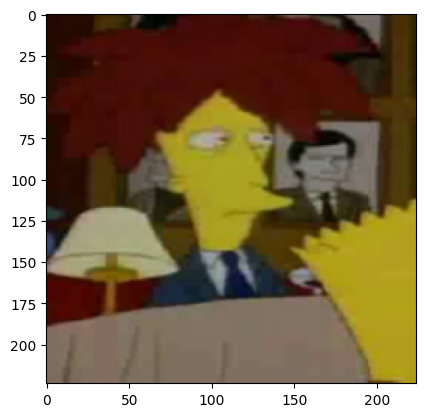

In [ ]:
image_tensor, label = next(iter(train_loader))
print(f"Числовая метка класса: {label[0]}")
print(f"Текстовая метка класса: {label_encoder.inverse_transform([label[0],])}")
imshow(image_tensor[0])

In [ ]:
def show_images(n_rows, n_cols, dataset):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, ax = plt.subplots(nrows=n_rows, ncols=n_cols, figsize = (n_cols*4, n_rows*4), sharey=True, sharex=True)

  for fig_x in ax.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # получаем изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()
    fig_x.set_axis_off()
  return None

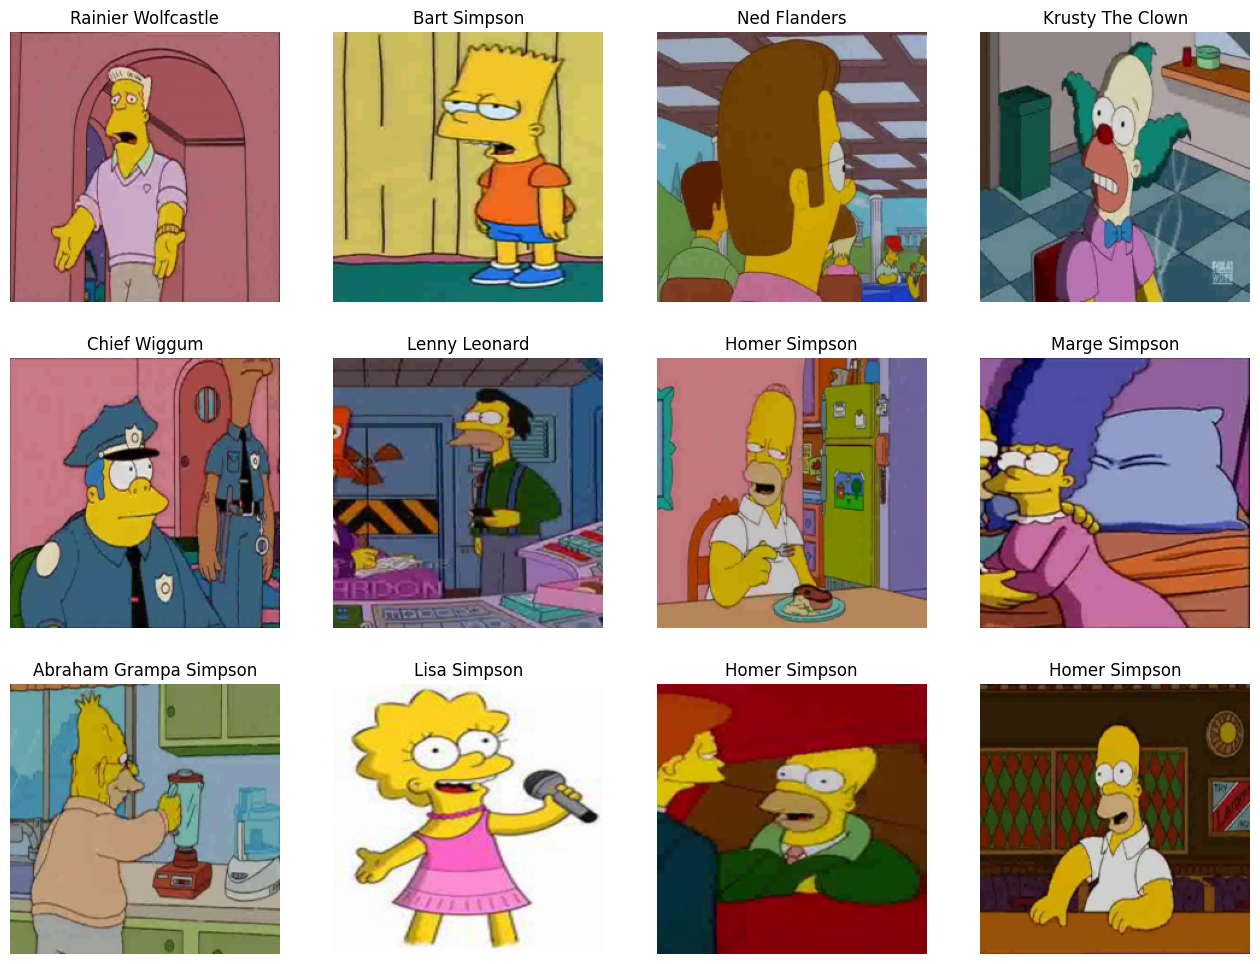

In [ ]:
show_images(n_rows = 3, n_cols = 4, dataset = val_dataset)

## Построение нейросети

### Модель

In [ ]:
class SimpleCnn(nn.Module):
    """
    Очень простая сверточная нейронная сеть для классификации изображений.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Параметры:
    ----------
    n_classes : int
        Количество классов для классификации.

    Примечание:
    ----------
    Входные изображения должны иметь размерность (3, H, W), где
    3 - слои rgb для цветной картинки, а H и W - высота и ширина изображения,
    соответственно. Размер выходного тензора будет равен (n_classes).

    Методы:
    -------
    forward(x):
        Пропускает входные данные через сеть и возвращает логиты для
        каждого класса.
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(in_channels=3, out_channels=8, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv2 = nn.Sequential(
            nn.Conv2d(in_channels=8, out_channels=16, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv3 = nn.Sequential(
            nn.Conv2d(in_channels=16, out_channels=32, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv4 = nn.Sequential(
            nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )
        self.conv5 = nn.Sequential(
            nn.Conv2d(in_channels=64, out_channels=96, kernel_size=3),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2)
        )

        self.out = nn.Linear(96 * 5 * 5, n_classes)


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.conv4(x)
        x = self.conv5(x)

        x = x.view(x.size(0), -1)
        logits = self.out(x)
        return logits

*Описание слоев*:

1. размерность входа: $3\times 224 \times 224$
2. размерность после 1-го слоя (Conv2d + ReLU + MaxPool2d):  $8 \times 111 \times 111$
3. после 2-го слоя: $16 \times 54 \times 54$
4. после 3-го слоя: $32 \times 26 \times 26$
5. после 4-го слоя: $64 \times 12 \times 12$
6. после 5-го слоя: $96 \times 5 \times 5$
7. после полносвязного слоя (выход модели): количество классов

In [ ]:
model_simple_cnn = SimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_simple_cnn.to(DEVICE)
torchsummary.summary(model_simple_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1          [-1, 8, 222, 222]             224
              ReLU-2          [-1, 8, 222, 222]               0
         MaxPool2d-3          [-1, 8, 111, 111]               0
            Conv2d-4         [-1, 16, 109, 109]           1,168
              ReLU-5         [-1, 16, 109, 109]               0
         MaxPool2d-6           [-1, 16, 54, 54]               0
            Conv2d-7           [-1, 32, 52, 52]           4,640
              ReLU-8           [-1, 32, 52, 52]               0
         MaxPool2d-9           [-1, 32, 26, 26]               0
           Conv2d-10           [-1, 64, 24, 24]          18,496
             ReLU-11           [-1, 64, 24, 24]               0
        MaxPool2d-12           [-1, 64, 12, 12]               0
           Conv2d-13           [-1, 96, 10, 10]          55,392
             ReLU-14           [-1, 96,

## Функция для работы с моделью

In [11]:
from sklearn.metrics import f1_score

### Функция для обучения модели на одной эпохе

In [12]:
def fit_one_epoch(model, train_dataloader, criterion, optimizer):
  all_preds = []
  all_labels = []
  model.train()

  for X_batch, y_batch in tqdm(train_dataloader):
    X_batch = X_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)

    optimizer.zero_grad()
    outp = model(X_batch)
    loss = criterion(outp, y_batch)
    loss.backward()
    optimizer.step()

    preds = outp.argmax(-1)
    all_preds.append(preds.cpu())
    all_labels.append(y_batch.cpu())

  all_preds = torch.cat(all_preds, dim=0)
  all_labels = torch.cat(all_labels, dim=0)

  return all_preds, all_labels

### Функция валидации модели на одной эпохе

In [13]:
def validate_one_epoch(model, val_dataloader):
  model.eval()
  all_preds = []
  all_labels = []

  for X_batch, y_batch in tqdm(val_dataloader):
    X_batch = X_batch.to(DEVICE)
    y_batch = y_batch.to(DEVICE)

    with torch.no_grad():
      outp = model(X_batch)
      preds = outp.argmax(1)

    all_preds.append(preds.cpu())
    all_labels.append(y_batch.cpu())

  all_preds = torch.cat(all_preds, dim = 0)
  all_labels = torch.cat(all_labels, dim = 0)

  return all_preds, all_labels

### Функция реализации полного цикла обучения

In [14]:
def train_func(model, num_epochs, train_dataloader, val_dataloader, criterion, optimizer, start_epoch=0):
  model.to(DEVICE)
  history = {
      'train_f1': [],
      'val_f1': []
  }

  for epoch in range(start_epoch, start_epoch+num_epochs):
    train_preds, train_labels = fit_one_epoch(model, train_dataloader, criterion, optimizer)
    train_f1 = f1_score(train_labels, train_preds, average='weighted')

    val_preds, val_labels = validate_one_epoch(model, val_dataloader)
    val_f1 = f1_score(val_labels, val_preds, average='weighted')

    history['train_f1'].append(train_f1)
    history['val_f1'].append(val_f1)

    print(f"Train F1: {train_f1:.4f}")
    print(f"Val F1: {val_f1:.4f}")

  return history

## Применение модели к данным

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)

Запустим обучение сети

In [ ]:
history = train_func(model_simple_cnn, 5, train_loader, val_loader, criterion, optimizer)
torch.save(model_simple_cnn.state_dict(), 'model_simple_cnn_weights_5.pth')

100%|██████████| 82/82 [00:41<00:00,  1.98it/s]


Train F1: 0.9752
Val F1: 0.7939


100%|██████████| 82/82 [00:41<00:00,  1.98it/s]


Train F1: 0.9820
Val F1: 0.8096


100%|██████████| 82/82 [00:41<00:00,  1.99it/s]


Train F1: 0.9763
Val F1: 0.7979


100%|██████████| 82/82 [00:40<00:00,  2.02it/s]


Train F1: 0.9790
Val F1: 0.8114


100%|██████████| 82/82 [00:41<00:00,  2.00it/s]

Train F1: 0.9844
Val F1: 0.8040


Дообучим нашу сеть

In [ ]:
model_simple_cnn.load_state_dict(torch.load('model_simple_cnn_weights_5.pth'))
new_history = train_func(model_simple_cnn, 5, train_loader, val_loader, criterion, optimizer, start_epoch = 5)
torch.save(model_simple_cnn.state_dict(), 'model_simple_cnn_weights_10.pth')

100%|██████████| 82/82 [00:42<00:00,  1.92it/s]


Train F1: 0.9873
Val F1: 0.8119


100%|██████████| 82/82 [00:42<00:00,  1.92it/s]


Train F1: 0.9876
Val F1: 0.8075


100%|██████████| 82/82 [00:40<00:00,  2.01it/s]


Train F1: 0.9827
Val F1: 0.8076


100%|██████████| 82/82 [00:40<00:00,  2.02it/s]


Train F1: 0.9766
Val F1: 0.7987


100%|██████████| 82/82 [00:39<00:00,  2.05it/s]

Train F1: 0.9905
Val F1: 0.8000


Построим график динамики метрик модели по ходу обучения

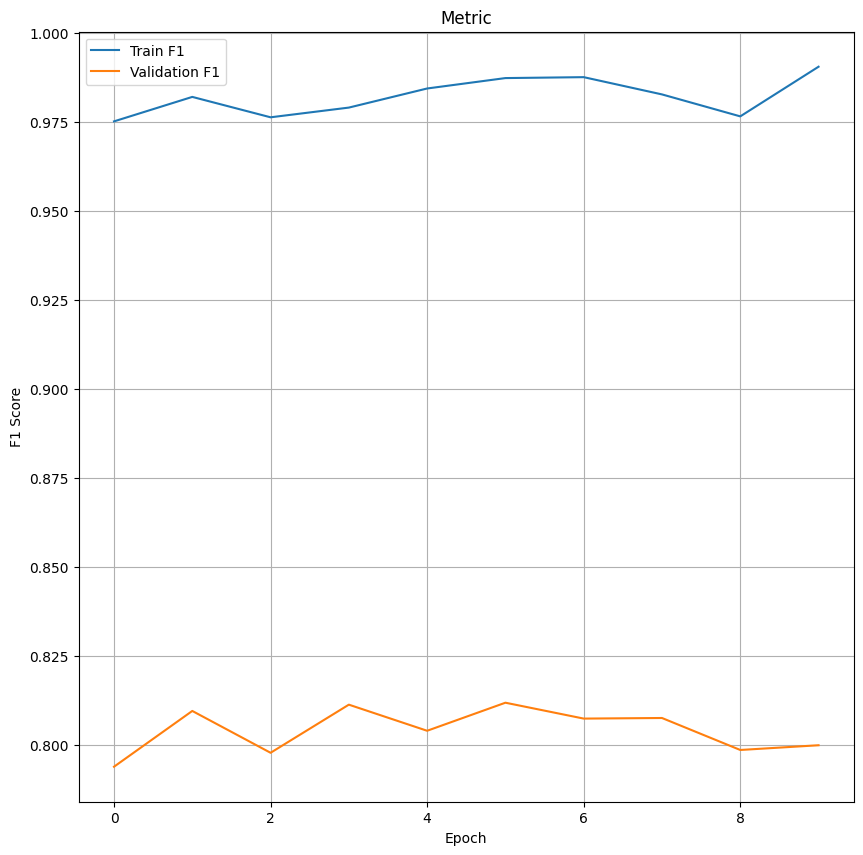

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(history['train_f1']+new_history['train_f1'], label='Train F1')
plt.plot(history['val_f1']+new_history['val_f1'], label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Metric')
plt.legend()
plt.grid(True)

plt.show()

Сделаем визуализацию, чтобы посмотреть насколько сеть уверена в своих ответах.

In [ ]:
import matplotlib.patches as patches
from matplotlib.font_manager import FontProperties

@torch.no_grad()
def show_images2(n_rows, n_cols, dataset, model):
  # функция выводит изображения в n_rows рядов и n_cols столбцов
  fig, axs = plt.subplots(nrows=n_rows, ncols=n_cols, figsize=(n_cols * 4, n_rows * 4), \
                        sharey=True, sharex=True)

  for fig_x in axs.flatten(): # цикл повторяется (n_rows * n_cols) раз
    random_characters = int(np.random.uniform(0, len(dataset))) # берем случайное число в диапазоне [0; len(dataset))
    im_val, label = dataset[random_characters] # выводим изображение (тензорная форма)
    img_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([label])[0].split('_')))  # числовую метку класса преобразуем в текстовую и немного отформатируем
    imshow(im_val.data.cpu(), title=img_label, plt_ax=fig_x) # отобразим изображение и метку класса с помощью написанной ранее функции imshow()

    # ниже представлен код для добавления на изображение подписи с вероятностью класса
    actual_text = "Actual : {}".format(img_label)


    font0 = FontProperties()
    font = font0.copy()

    # наша модель возвращает логиты, поэтому для получения вероятностей классов не забываем применить softmax:
    prob_pred = nn.functional.softmax(model(im_val.unsqueeze(0).to(DEVICE)), dim = -1).cpu().numpy()

    predicted_proba = np.max(prob_pred)*100 # берем максимальную вероятность класса
    y_pred = np.argmax(prob_pred) # берем числовую метку класса, для которого вероятность максимальна

    predicted_label = " ".join(map(lambda x: x.capitalize(), \
                             label_encoder.inverse_transform([y_pred])[0].split('_')))
    predicted_text = "{}:\n {:.1f}%".format(predicted_label, predicted_proba)

    fig_x.add_patch(patches.Rectangle((0, 190), 7*len(predicted_label), 25,color='white'))
    fig_x.text(2, 195, predicted_text , horizontalalignment='left', fontproperties=font,
                    verticalalignment='top',fontsize=8, color='black',fontweight='bold')
    fig_x.set_axis_off()

  return None

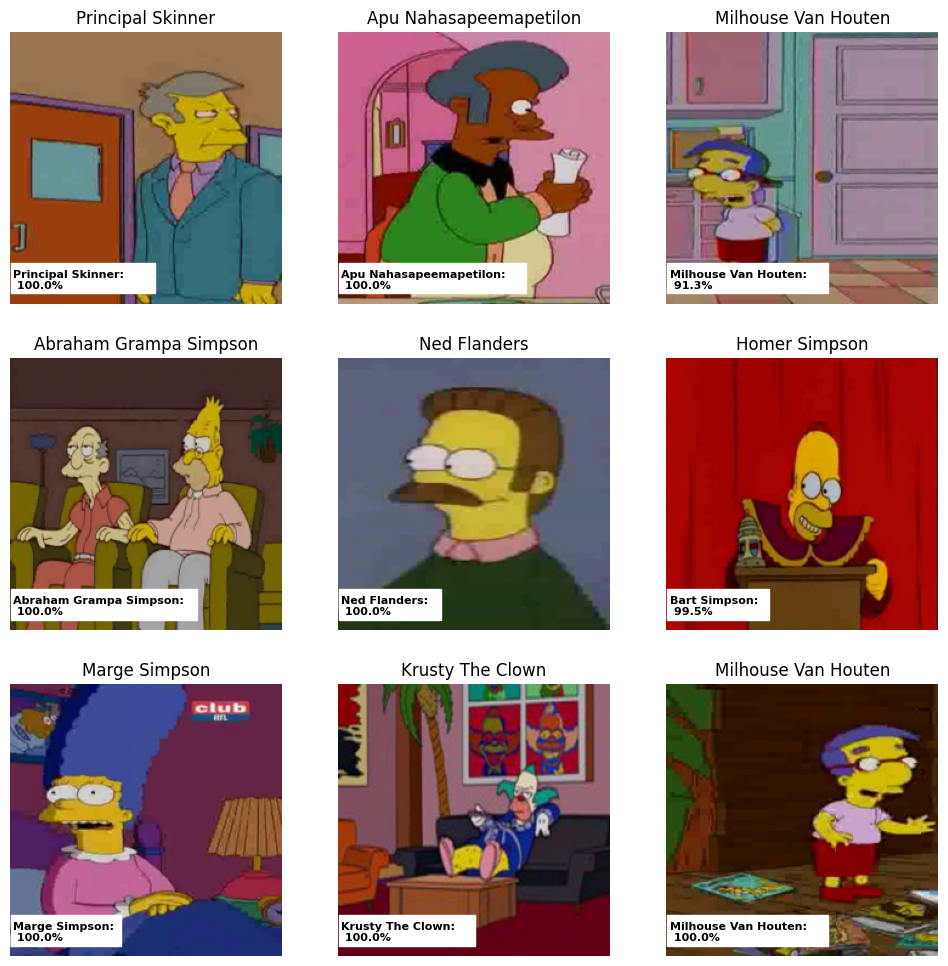

In [ ]:
show_images2(n_rows = 3, n_cols = 3, dataset = val_dataset, model = model_simple_cnn)

## Submit на Kaggle

Создадим loader для тестовых данных

In [ ]:
test_dataset = SimpsonDataset(test_files, label_encoder = label_encoder, mode = 'test')
test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 64)

Воспользуемся функцией predict, которая возвращает предсказанные числовые метки для всех объектов в лоадере.

In [ ]:
def predict(model, loader):
  model.eval()
  all_predictions = torch.tensor([]).to(DEVICE).int()
  print("Test mode...")
  for inputs in tqdm_notebook(loader):
    inputs = inputs.to(DEVICE)

    with torch.no_grad():
      outputs = model(inputs)

      predictions = outputs.argmax(-1).int()
      all_predictions = torch.cat((all_predictions, predictions), 0)
  return all_predictions.cpu()

Получаем предсказание метод классов для тестовых данных

In [ ]:
predicted_numeric_labels = predict(model_simple_cnn, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

преобразуем их в текстовые метки:

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

Загрузим пример файла для загрузки на Kaggle (проверьте путь, по которому у вас лежит файл sample_submission.csv и при необходимости скорректируйте путь в коде ниже):

In [ ]:
import pandas as pd
sample_submission = pd.read_csv("/content/sample_submission.csv")
sample_submission.head(10)

,Id,Expected
0,img0.jpg,bart_simpson
1,img1.jpg,bart_simpson
2,img2.jpg,bart_simpson
3,img3.jpg,bart_simpson
4,img4.jpg,bart_simpson
5,img5.jpg,bart_simpson
6,img6.jpg,bart_simpson
7,img7.jpg,bart_simpson
8,img8.jpg,bart_simpson
9,img9.jpg,bart_simpson


In [ ]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [ ]:
my_submission.to_csv('simple_cnn_baseline.csv', index=False)

## Улучшение модели

### Увеличим разнообразие обучающей выборки

Создадим новый класс AugmentedSimpsonDataset, наследующий SimpsonDataset и переопределим функцию transform_images_to_tensors

In [ ]:
class AugmentedSimpsonDataset(SimpsonDataset):
  def transform_images_to_tensors(self, image):
    if self.mode == 'train':
      transform = v2.Compose([
          v2.PILToTensor(),
          v2.ToDtype(torch.float32, scale = True),
          v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
          v2.RandomHorizontalFlip(p=0.5),
          v2.ColorJitter(brightness = 0.1, contrast = 0.1, saturation = 0.1),
          v2.RandomRotation(degrees=10),
          v2.Resize(RESCALE_SIZE),
      ])
    else:
      transform = v2.Compose([
          v2.PILToTensor(),
          v2.ToDtype(torch.float32, scale = True),
          v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD),
          v2.Resize(RESCALE_SIZE)
      ])

    tensor_transformed = transform(image)
    return (tensor_transformed)

Аугментации:
- RandomHorizontalFlip: персонажи могут быть повернуты (50% изображний)
- ColorJitter: разное освещение и цвета на фото
- RandomRotation: наклон на 10 градусов

Создадим датасеты и даталоадеры

In [ ]:
train_dataset_aug = AugmentedSimpsonDataset(train_files, label_encoder=label_encoder, mode='train')
train_loader_aug = DataLoader(train_dataset, batch_size=batch_size, shuffle = True)
loaders_aug = {'train': train_loader, 'val': val_loader}

Применим исходную модель к данным

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 1e-3)

In [ ]:
history_aug = train_func(model_simple_cnn, 10, train_loader_aug, val_loader, criterion, optimizer)
torch.save(model_simple_cnn.state_dict(), 'model_simple_cnn_aug__weights_10.pth')

100%|██████████| 82/82 [00:39<00:00,  2.07it/s]


Train F1: 0.9839
Val F1: 0.7988


100%|██████████| 82/82 [00:39<00:00,  2.09it/s]


Train F1: 0.9910
Val F1: 0.8111


100%|██████████| 82/82 [00:39<00:00,  2.07it/s]


...

Train F1: 0.9880
Val F1: 0.8181


100%|██████████| 82/82 [00:40<00:00,  2.03it/s]


Train F1: 0.9912
Val F1: 0.8019


100%|██████████| 82/82 [00:39<00:00,  2.09it/s]

Train F1: 0.9889
Val F1: 0.8101


Визуализируем результат

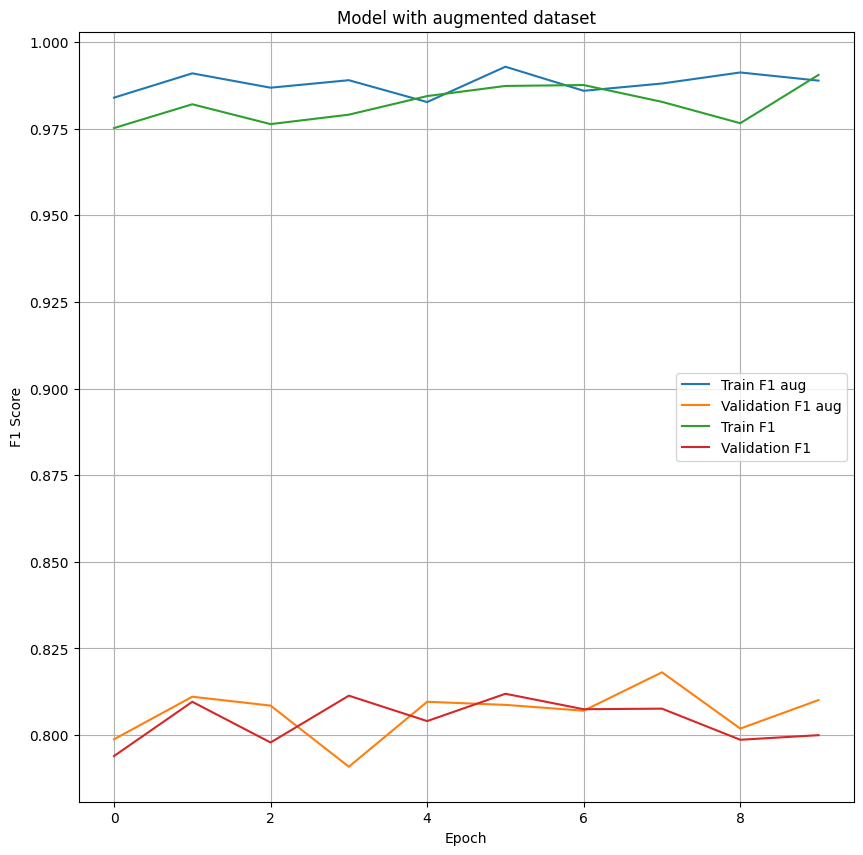

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(history_aug['train_f1'], label='Train F1 aug')
plt.plot(history_aug['val_f1'], label='Validation F1 aug')
plt.plot(history['train_f1']+new_history['train_f1'], label='Train F1')
plt.plot(history['val_f1']+new_history['val_f1'], label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Model with augmented dataset')
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
test_dataset = AugmentedSimpsonDataset(test_files, label_encoder = label_encoder, mode = 'test')
test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 64)

In [ ]:
predicted_numeric_labels = predict(model_improved_cnn, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [ ]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

In [ ]:
my_submission_aug = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission_aug.head(10)

,Id,Expected
0,img0.jpg,maggie_simpson
1,img1.jpg,lionel_hutz
2,img10.jpg,sideshow_mel
3,img100.jpg,gil
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,charles_montgomery_burns
6,img103.jpg,maggie_simpson
7,img104.jpg,charles_montgomery_burns
8,img105.jpg,maggie_simpson
9,img106.jpg,charles_montgomery_burns


In [ ]:
my_submission_aug.to_csv('simple_cnn_aug.csv', index=False)

Результат оказался очень плохим - 0,03.

### Изменим архитектуру

Дообучим исходную модель еще на 5 эпох

In [ ]:
model_simple_cnn.load_state_dict(torch.load('model_simple_cnn_weights_10.pth'))
new_2_history = train_func(model_simple_cnn, 5, train_loader, val_loader, criterion, optimizer, start_epoch = 10)
torch.save(model_simple_cnn.state_dict(), 'model_simple_cnn_weights_15.pth')

100%|██████████| 82/82 [00:40<00:00,  2.03it/s]


Train F1: 0.9809
Val F1: 0.8094


100%|██████████| 82/82 [00:39<00:00,  2.05it/s]


Train F1: 0.9836
Val F1: 0.8096


100%|██████████| 82/82 [00:39<00:00,  2.07it/s]


Train F1: 0.9827
Val F1: 0.8057


100%|██████████| 82/82 [00:40<00:00,  2.03it/s]


Train F1: 0.9899
Val F1: 0.8074


100%|██████████| 82/82 [00:41<00:00,  1.99it/s]

Train F1: 0.9882
Val F1: 0.7984


In [ ]:
test_dataset = SimpsonDataset(test_files, label_encoder = label_encoder, mode = 'test')
test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 64)

predicted_numeric_labels = predict(model_simple_cnn, test_loader)

predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

my_submission_more_train = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission_more_train.head(10)

my_submission_more_train.to_csv('simple_cnn_more_train.csv', index=False)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

Снова визуализиурем результаты

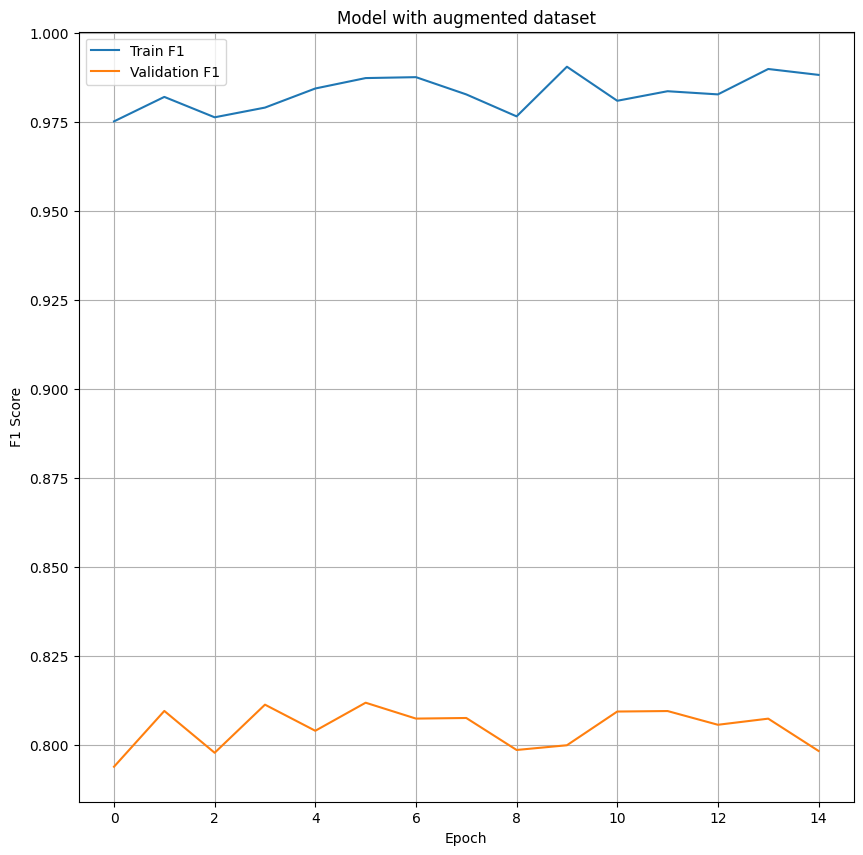

In [ ]:
plt.figure(figsize=(10, 10))
plt.plot(history['train_f1']+new_history['train_f1']+new_2_history['train_f1'], label='Train F1')
plt.plot(history['val_f1']+new_history['val_f1']+new_2_history['val_f1'], label='Validation F1')
plt.xlabel('Epoch')
plt.ylabel('F1 Score')
plt.title('Model with augmented dataset')
plt.legend()
plt.grid(True)

plt.show()

В целом train растет, а вот validation - падает, происходит переобучение. Попробуем сделать новую архитектуру, для которой добавим dropout и batchnorm

In [ ]:
class ImprovedSimpleCnn(nn.Module):
    """
    Улучшенная сверточная нейронная сеть с BatchNorm и Dropout для борьбы с переобучением.

    Эта сеть состоит из пяти сверточных слоев, каждый из которых
    включает в себя операцию свертки, функцию активации ReLU и операцию
    пулинга (max-pooling). На выходе используется полносвязный слой
    для классификации на заданное количество классов.

    Особенности:
      - BatchNorm2d после каждого сверточного слоя для стабилизации обучения
      - Dropout в сверточных и полносвязных слоях для регуляризации
    """

    def __init__(self, n_classes):
        super().__init__()
        self.conv1 = nn.Sequential(
            nn.Conv2d(3, 16, kernel_size=3, padding=1),
            nn.BatchNorm2d(16),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv2 = nn.Sequential(
            nn.Conv2d(16, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.conv3 = nn.Sequential(
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(),
            nn.MaxPool2d(2)
        )

        self.global_pool = nn.AdaptiveAvgPool2d((1, 1))

        self.classifier = nn.Sequential(
            nn.Dropout(0.5),
            nn.Linear(64, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, n_classes)
        )


    def forward(self, x):
        x = self.conv1(x)
        x = self.conv2(x)
        x = self.conv3(x)
        x = self.global_pool(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

- BatchNorm2d - нормализует активации, ускоряет обучение
- Dropout2d - выключает целые каналы для регуляризации
- BatchNorm1d - нормализация для полносвязного слоя

In [ ]:
model_improved_cnn = ImprovedSimpleCnn(n_classes = len(np.unique(train_val_labels)))
model_improved_cnn.to(DEVICE)
torchsummary.summary(model_improved_cnn, (3, 224, 224))

----------------------------------------------------------------
        Layer (type)               Output Shape         Param #
            Conv2d-1         [-1, 16, 224, 224]             448
       BatchNorm2d-2         [-1, 16, 224, 224]              32
              ReLU-3         [-1, 16, 224, 224]               0
         MaxPool2d-4         [-1, 16, 112, 112]               0
            Conv2d-5         [-1, 32, 112, 112]           4,640
       BatchNorm2d-6         [-1, 32, 112, 112]              64
              ReLU-7         [-1, 32, 112, 112]               0
         MaxPool2d-8           [-1, 32, 56, 56]               0
            Conv2d-9           [-1, 64, 56, 56]          18,496
      BatchNorm2d-10           [-1, 64, 56, 56]             128
             ReLU-11           [-1, 64, 56, 56]               0
        MaxPool2d-12           [-1, 64, 28, 28]               0
AdaptiveAvgPool2d-13             [-1, 64, 1, 1]               0
          Dropout-14                   

Применим модель к данным

In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model_simple_cnn.parameters(), lr = 0.001)

In [ ]:
history_improved = train_func(model_improved_cnn, 10, train_loader, val_loader, criterion, optimizer)
torch.save(model_improved_cnn.state_dict(), 'model_improved_cnn_weights_10.pth')

  0%|          | 1/246 [00:00<03:22,  1.21it/s]


KeyboardInterrupt: 

Разные гиперпараметры и изменение слоев не приносят результатов - модель обучается намного хуже. \
Попробуем transfer learning

### Transfer learning

#### ResNet18

In [15]:
import torchvision.models as models
from torchvision import transforms as T

model_resnet = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)

Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 188MB/s]


In [16]:
print(f"Последний слой: {model_resnet.fc}")

Последний слой: Linear(in_features=512, out_features=1000, bias=True)


Создадим класс для ResNet с адаптацией под наши данные

In [17]:
class ResNet18Classifier(nn.Module):
  def __init__(self, n_classes, freeze_backbone=True, dropout_rate=0.5):
    super().__init__()

    self.backbone = models.resnet18(weights = models.ResNet18_Weights.IMAGENET1K_V1)

    if freeze_backbone:
      for param in self.backbone.parameters():
        param.requires_grad = False

    in_features = self.backbone.fc.in_features
    self.backbone.fc = nn.Sequential(
        nn.Dropout(dropout_rate),
        nn.Linear(in_features, 256),
        nn.ReLU(),
        nn.BatchNorm1d(256),
        nn.Dropout(dropout_rate / 2),
        nn.Linear(256, n_classes)
    )

  def forward(self, x):
    return self.backbone(x)

Создадим модель

In [18]:
model_resnet = ResNet18Classifier(n_classes=len(np.unique(train_val_labels)), freeze_backbone=True, dropout_rate=0.5).to(DEVICE)

Создадим даталоадер

Датасет оставим исходный, поменяем порядок операций

In [19]:
class SimpsonDatasetResNet(Dataset):
  def __init__(self, files, label_encoder, mode):
    super().__init__()
    self.files = sorted(files)
    self.mode = mode
    if self.mode not in DATA_MODES:
        print(f"{self.mode} is not correct; correct modes: {DATA_MODES}")
        raise NameError

    self.label_encoder = label_encoder
    self.len_ = len(self.files)

  def __len__(self):
    return self.len_

  def __getitem__(self, index):
    x = self.load_image(self.files[index])
    x = self.transform_images_to_tensors(x)

    if self.mode == 'test':
      return x
    else:
      path = self.files[index]
      y = self.label_encoder.transform([path.parent.name,]).item()
      return x, y

  # принимает путь к изображению и возвращает само изображение
  def load_image(self, file):
    image = Image.open(file)
    image.load()
    return image

  # преобразует изображение в тензор
  def transform_images_to_tensors(self, image):
    if self.mode == 'train':
      transform = v2.Compose([
          v2.PILToTensor(),
          v2.ToDtype(torch.float32, scale = True),
          v2.Resize(RESCALE_SIZE),
          v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)
      ])
    else:
      transform = v2.Compose([
          v2.PILToTensor(),
          v2.ToDtype(torch.float32, scale = True),
          v2.Resize(RESCALE_SIZE),
          v2.Normalize(NORMALIZE_MEAN, NORMALIZE_STD)
      ])

    tensor_transformed = transform(image)
    return (tensor_transformed)

In [20]:
train_dataset_resnet = SimpsonDatasetResNet(train_files, label_encoder=label_encoder, mode='train')
val_dataset_resnet = SimpsonDatasetResNet(val_files, label_encoder=label_encoder, mode='val')

In [21]:
batch_size = 64

In [22]:
train_loader_resnet = DataLoader(train_dataset_resnet, batch_size=batch_size, shuffle = True)
val_loader_resnet = DataLoader(val_dataset_resnet, batch_size=batch_size, shuffle = False)
loaders = {'train': train_loader_resnet, 'val': val_loader_resnet}

In [23]:
optimizer_resnet = torch.optim.Adam(
    model_resnet.backbone.fc.parameters(),
    lr=0.001
)

criterion = torch.nn.CrossEntropyLoss()

In [ ]:
history_resnet = train_func(model_resnet, 10, train_loader_resnet, val_loader_resnet, criterion, optimizer_resnet)
torch.save(model_resnet.state_dict(), 'model_resnet_10.pth')

100%|██████████| 82/82 [00:42<00:00,  1.94it/s]


Train F1: 0.3803
Val F1: 0.6539


100%|██████████| 82/82 [00:41<00:00,  1.95it/s]


Train F1: 0.4814
Val F1: 0.6795


100%|██████████| 82/82 [00:41<00:00,  1.99it/s]


...

Train F1: 0.5339
Val F1: 0.7088


100%|██████████| 82/82 [00:41<00:00,  1.96it/s]


Train F1: 0.5341
Val F1: 0.7074


100%|██████████| 82/82 [00:49<00:00,  1.66it/s]

Train F1: 0.5360
Val F1: 0.7147


После обучения нескольких эпох прогресса дальше не наблюдается, попробуем использовать более продвинутую модель ResNet

#### ResNet50

Напишем класс

In [24]:
class ResNet50Classifier(nn.Module):
  def __init__(self, n_classes, freeze_backbone=True):
    super().__init__()
    self.backbone = models.resnet50(weights = models.ResNet50_Weights.IMAGENET1K_V2)

    if freeze_backbone:
        for param in self.backbone.parameters():
            param.requires_grad = False

    in_features = self.backbone.fc.in_features
    self.backbone.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(0.3),
        nn.Linear(512, n_classes)
    )

  def forward(self, x):
    return self.backbone(x)

In [25]:
model_resnet50 = ResNet50Classifier(n_classes=len(np.unique(train_val_labels)), freeze_backbone=True).to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 195MB/s]


In [26]:
optimizer_resnet50 = torch.optim.Adam(model_resnet50.backbone.fc.parameters(), lr=0.001)

In [27]:
history_resnet50 = train_func(model_resnet50, 10, train_loader_resnet, val_loader_resnet, criterion, optimizer_resnet50)
torch.save(model_resnet50.state_dict(), 'model_resnet50_10.pth')

100%|██████████| 82/82 [00:49<00:00,  1.67it/s]


Train F1: 0.5576
Val F1: 0.7634


100%|██████████| 82/82 [00:49<00:00,  1.66it/s]


Train F1: 0.6881
Val F1: 0.8026


100%|██████████| 82/82 [00:49<00:00,  1.65it/s]


Train F1: 0.7166
Val F1: 0.8131


 63%|██████▎   | 154/246 [01:39<00:59,  1.54it/s]


KeyboardInterrupt: 

Снова мы можем видеть, что модель обучается до определенного момента, затем стоит на месте. Попробуем разморозить больше слоев

#### ResNet50 больше слоев

In [30]:
class ResNet50FineTune(nn.Module):
  def __init__(self, n_classes):
    super().__init__()
    self.backbone = models.resnet50(weights = models.ResNet50_Weights.IMAGENET1K_V2)

    for param in self.backbone.parameters():
        param.requires_grad = False

    for param in self.backbone.layer4.parameters():
            param.requires_grad = True

    in_features = self.backbone.fc.in_features
    self.backbone.fc = nn.Sequential(
        nn.Dropout(0.5),
        nn.Linear(in_features, 512),
        nn.ReLU(),
        nn.BatchNorm1d(512),
        nn.Dropout(0.3),
        nn.Linear(512, n_classes)
    )

  def forward(self, x):
    return self.backbone(x)

In [31]:
model_resnet50_finetune = ResNet50FineTune(n_classes=len(np.unique(train_val_labels))).to(DEVICE)

In [32]:
optimizer_resnet50_finetune = torch.optim.Adam([
    {'params': model_resnet50_finetune.backbone.layer4.parameters(), 'lr': 0.0001},
    {'params': model_resnet50_finetune.backbone.fc.parameters(), 'lr': 0.001},
], weight_decay=1e-4)

In [33]:
history_resnet50_finetune = train_func(model_resnet50_finetune, 10, train_loader_resnet, val_loader_resnet, criterion, optimizer_resnet50_finetune)
torch.save(model_resnet50_finetune.state_dict(), 'model_resnet50_finetune_10.pth')

100%|██████████| 82/82 [00:50<00:00,  1.63it/s]


Train F1: 0.7386
Val F1: 0.9031


100%|██████████| 82/82 [00:49<00:00,  1.66it/s]


Train F1: 0.9399
Val F1: 0.9319


100%|██████████| 82/82 [00:50<00:00,  1.63it/s]


...

Train F1: 0.9976
Val F1: 0.9469


100%|██████████| 82/82 [00:50<00:00,  1.61it/s]


Train F1: 0.9976
Val F1: 0.9438


100%|██████████| 82/82 [00:50<00:00,  1.63it/s]

Train F1: 0.9963
Val F1: 0.9495


Модель показывает высокий score и на train, и на val

Создадим loader для тестовых данных

In [34]:
test_dataset = SimpsonDatasetResNet(test_files, label_encoder = label_encoder, mode = 'test')
test_loader = DataLoader(test_dataset, shuffle = False, batch_size = 64)

In [35]:
def predict(model, loader):
  model.eval()
  all_predictions = torch.tensor([]).to(DEVICE).int()
  print("Test mode...")
  for inputs in tqdm_notebook(loader):
    inputs = inputs.to(DEVICE)

    with torch.no_grad():
      outputs = model(inputs)

      predictions = outputs.argmax(-1).int()
      all_predictions = torch.cat((all_predictions, predictions), 0)
  return all_predictions.cpu()

In [36]:
predicted_numeric_labels = predict(model_resnet50_finetune, test_loader)

Test mode...


  0%|          | 0/16 [00:00<?, ?it/s]

In [37]:
predicted_text_labels = label_encoder.inverse_transform(predicted_numeric_labels)

In [38]:
import pandas as pd

In [39]:
my_submission = pd.DataFrame({'Id': [path.name for path in test_files], 'Expected': predicted_text_labels})
my_submission.head(10)

,Id,Expected
0,img0.jpg,nelson_muntz
1,img1.jpg,bart_simpson
2,img10.jpg,ned_flanders
3,img100.jpg,chief_wiggum
4,img101.jpg,apu_nahasapeemapetilon
5,img102.jpg,kent_brockman
6,img103.jpg,edna_krabappel
7,img104.jpg,chief_wiggum
8,img105.jpg,lisa_simpson
9,img106.jpg,kent_brockman


In [40]:
my_submission.to_csv('resnet50_cnn.csv', index=False)